# Open-set retrieval test
Open-set retrieval is an AI concept that searches for information in an uncontrolled environment where query items may belong to entirely unseen or unclassified categories. Unlike traditional closed-set systems that only match items with pre-defined labels, open-set retrieval detects in-distribution targets while intelligently rejecting out-of-distribution, unknown, or irrelevant inputs

**Practically:**

Hold out one TF entirely from the reference library (e.g., remove all Rtg1), then query Rtg1 test traces against the remaining 5 classes. If the embedding is genuinely encoding TF dynamics, Rtg1 should cluster near its nearest biological neighbour (likely another glucose-responsive TF) rather than scattering randomly. This is the experiment that directly validates or falsifies obur zero-shot claim.

**Why Open-Set Retrieval Matters?**

Real-World Unpredictability: In practical applications, users frequently search for novel objects, concepts, or documents. Closed-set models are forced to misclassify these novelties into one of the "known" buckets.

**Biologically-Relevant Question Asked:**

Given the reference library of Nrg1 @ 3 glucose concentrations, can we correctly guess the conditions of Rtg1 @ 3 glucose concentrations? If yes, this would suggest that the embedding is capturing biologically relevant information about TF dynamics, even for unseen TFs.

## 1. Define the hold-out scheme: Full TF hold-out of Rtg1

Remove all Rtg1 traces from the reference library. Reference = Nrg1 @ 3 glucose conditions (or all non-Rtg1 TF@condition classes if you expand beyond the current 6-class setup). Query = Rtg1 @ 3 conditions.

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))

RANDOM_STATE = 42

# remove Rtg1 from the reference library
REFERENCE_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
]

QUERY_CLASSES = [
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

IY032_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY032")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]

EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# this is the k for top k retrieval and recall@k metrics
K = 5

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

print(f"Metadata entries: {len(LABEL_LOOKUP)}")
print("Unique TFs:",        sorted(metadata["tf"].unique()))
print("Unique conditions:", sorted(metadata["condition"].unique()))


Metadata entries: 66
Unique TFs: ['Cat8', 'Dot6', 'Maf1', 'Mig1', 'Mig2', 'Msn2', 'Nrg1', 'Rtg1', 'Sfp1', 'Tod6']
Unique conditions: ['0.01% galactose', '0.01% glucose', '0.1% glucose', '2% galactose', '2% glucose (mock/steady)']


In [3]:
from utils.experimental_time_series import load_labelled_time_series_csvs

# we only care about steady-state time series for now
print("=" * 70)
print(f"STEADY-STATE  ({SS_DATA_DIR.name})")
print("=" * 70)
ss_ts_raw, ss_label_strs = load_labelled_time_series_csvs(
        data_dir=SS_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
    )

# print()
# print("=" * 70)
# print(f"FULL  ({FULL_DATA_DIR.name})")
# print("=" * 70)
# full_ts_raw, full_label_strs = load_labelled_time_series_csvs(
#         data_dir=FULL_DATA_DIR,
#         file_re=FILE_RE,
#         label_lookup=LABEL_LOOKUP,
#         meta_cols=META_COLS,
#         excluded_exps=EXCLUDED_EXPS,
#     )


STEADY-STATE  (4_transformed_exp_time_series)
  18360/1106/GFP       -> Mig2 @ 0.1% glucose                            (233 cells, 122 tp)
  18360/1106/mCherry   -> Mig1 @ 0.1% glucose                            (233 cells, 23 tp)
  18360/898/GFP       -> Msn2 @ 0.1% glucose                            (254 cells, 116 tp)
  18360/898/mCherry   -> Mig1 @ 0.1% glucose                            (254 cells, 24 tp)
  18360/900/GFP       -> Mig1 @ 0.1% glucose                            (243 cells, 63 tp)
  18360/900/mCherry   -> Msn2 @ 0.1% glucose                            (243 cells, 178 tp)
  18464/756/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (209 cells, 201 tp)
  18464/756/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (209 cells, 237 tp)
  18464/764/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (202 cells, 178 tp)
  18464/764/mCherry   -> Dot6 @ 2% glucose (mock/steady)                (202 cells, 129 tp)
  18464/903/GFP       -> Dot6 @ 2% 

In [4]:
def print_class_summary(label_strs, kept_classes, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    print(f"{dataset_name} -- {len(counts)} total classes, {len(label_strs)} total cells")
    print(f"  Fixed {len(kept_classes)}-class selection (IY021 sanity check):")
    for cls in sorted(kept_classes):
        cnt = counts.get(cls, 0)
        print(f"  {cls:50s}: {cnt:5d}")
    missing = [c for c in kept_classes if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: missing classes with no data: {missing}")
    print(f"  -> Using {len(kept_classes)} classes")
    print(f"  Chance: 1/{len(kept_classes)} = {1/len(kept_classes):.4f}")
    return list(kept_classes)

ss_reference_classes   = print_class_summary(ss_label_strs,   REFERENCE_CLASSES, "Reference - Steady-state")
# full_reference_classes = print_class_summary(full_label_strs, REFERENCE_CLASSES, "Reference - Full")

ss_query_classes   = print_class_summary(ss_label_strs,   QUERY_CLASSES, "Query - Steady-state")
# full_query_classes = print_class_summary(full_label_strs, QUERY_CLASSES, "Query - Full")

Reference - Steady-state -- 32 total classes, 11980 total cells
  Fixed 3-class selection (IY021 sanity check):
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  -> Using 3 classes
  Chance: 1/3 = 0.3333
Query - Steady-state -- 32 total classes, 11980 total cells
  Fixed 3-class selection (IY021 sanity check):
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 3 classes
  Chance: 1/3 = 0.3333


## 2. Build reference library and run open-set retrieval across all checkpoints

Prepare the gallery (Nrg1 @ 3 glucose conditions) and probes (Rtg1 @ 3 glucose conditions) with a **shared truncation length** so both pass through the same encoder. All traces are used — no train/test split. Each group is normalised independently with StandardScaler. The retrieval is then run across all 34 SimCLR checkpoints.

In [5]:
# load all the SimCLR checkpoints
from utils.embeddings import load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

from utils.embeddings import parse_arch_from_name as parse_arch
from functools import partial
from utils.embeddings import make_checkpoint_short_label, make_unique_checkpoint_label

make_short_label = partial(make_checkpoint_short_label, norm_overrides=NORM_OVERRIDES)
make_unique_label = partial(make_unique_checkpoint_label, norm_overrides=NORM_OVERRIDES)

CKPT_DIRS      = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, _d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / _d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path":        p,
            "short_label": make_short_label(p),
            "label":       make_unique_label(p, len(MODEL_REGISTRY)),
            "experiment":  _d,
        })

EXP_COLOR_MAP = {
    "EXP-26-IY017": sns.color_palette("colorblind")[0],
    "EXP-26-IY022": sns.color_palette("colorblind")[1],
    "EXP-26-IY023": sns.color_palette("colorblind")[2],
    "EXP-26-IY024": sns.color_palette("colorblind")[4],
}

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128 #00                              d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128 #01                              d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16 164413                           d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16 061239                           d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16 151037                            d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #05                                d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #06                                d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16 162432                           d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16 154425                            d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128 #09                               d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16 140729                           d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16 023947                 

In [6]:
from utils.processing.imputation import fill_nans
from sklearn.neighbors import NearestNeighbors

def prepare_retrieval_data(ts_raw, label_strs, ref_classes, query_classes):
    """Prepare the reference gallery and query probes for open-set retrieval.

    Unlike prepare_dataset:
    - ALL traces are used (no train/test split).
    - Reference and query are truncated to a SHARED minimum length so both
      sets can be encoded by the same SimCLR model.
    - Each group is normalised independently with StandardScaler.
    """
    ref_set   = set(ref_classes)
    query_set = set(query_classes)
    ref_class_names   = sorted(ref_classes)
    query_class_names = sorted(query_classes)
    ref_label_to_int   = {c: i for i, c in enumerate(ref_class_names)}
    query_label_to_int = {c: i for i, c in enumerate(query_class_names)}

    ref_series, ref_lbls     = [], []
    query_series, query_lbls = [], []

    lbl_iter = iter(label_strs)
    for ts in ts_raw:
        ts_imp = fill_nans(np.asarray(ts, dtype=float))
        for row in ts_imp:
            lbl = next(lbl_iter)
            if lbl in ref_set:
                ref_series.append(row)
                ref_lbls.append(lbl)
            elif lbl in query_set:
                query_series.append(row)
                query_lbls.append(lbl)

    # Truncate BOTH groups to the same minimum length
    shared_min_T = min(len(s) for s in ref_series + query_series)

    # extract the raw data and labels for both groups
    X_ref_raw   = np.vstack([s[:shared_min_T] for s in ref_series])
    X_query_raw = np.vstack([s[:shared_min_T] for s in query_series])
    y_ref   = np.array([ref_label_to_int[l]   for l in ref_lbls])
    y_query = np.array([query_label_to_int[l] for l in query_lbls])

    # normalisation
    X_ref_norm   = StandardScaler().fit_transform(X_ref_raw)
    X_query_norm = StandardScaler().fit_transform(X_query_raw)

    print(f"Reference:  {X_ref_raw.shape[0]} cells × {shared_min_T} tp, "
          f"{len(ref_class_names)} classes")
    for i, c in enumerate(ref_class_names):
        print(f"  [{i}] {c}  ({(y_ref == i).sum()} cells)")
    print(f"Query:      {X_query_raw.shape[0]} cells × {shared_min_T} tp, "
          f"{len(query_class_names)} classes")
    for i, c in enumerate(query_class_names):
        print(f"  [{i}] {c}  ({(y_query == i).sum()} cells)")

    return dict(
        X_ref=X_ref_norm,     X_ref_raw=X_ref_raw,     y_ref=y_ref,
        X_query=X_query_norm, X_query_raw=X_query_raw, y_query=y_query,
        ref_class_names=ref_class_names,
        query_class_names=query_class_names,
        shared_min_T=shared_min_T,
    )


retrieval = prepare_retrieval_data(ss_ts_raw, ss_label_strs, REFERENCE_CLASSES, QUERY_CLASSES)
n_ref   = len(retrieval["ref_class_names"])
n_query = len(retrieval["query_class_names"])
# Short condition labels for plot axes (strip TF name prefix)
ref_short   = [c.replace("Nrg1 @ ", "") for c in retrieval["ref_class_names"]]
query_short = [c.replace("Rtg1 @ ", "") for c in retrieval["query_class_names"]]

Reference:  546 cells × 80 tp, 3 classes
  [0] Nrg1 @ 0.01% glucose  (231 cells)
  [1] Nrg1 @ 0.1% glucose  (231 cells)
  [2] Nrg1 @ 2% glucose (mock/steady)  (84 cells)
Query:      553 cells × 80 tp, 3 classes
  [0] Rtg1 @ 0.01% glucose  (275 cells)
  [1] Rtg1 @ 0.1% glucose  (200 cells)
  [2] Rtg1 @ 2% glucose (mock/steady)  (78 cells)


In [7]:
def open_set_retrieve(Z_gallery, y_gallery, Z_query, y_query, k=5):
    """For each query embedding find the k nearest gallery neighbours.

    Condition-matching accuracy: the top-1 retrieved gallery label must equal
    the query's condition index.  Both ref_class_names and query_class_names
    are sorted identically (0.01% → 0.1% → 2% glucose), so equal indices
    map to the same glucose condition.

    Returns
    -------
    dict with keys:
        acc_top1    – fraction of queries whose top-1 hit is condition-correct
        recall_at_k – fraction with any correct hit in the top-k
        top1_pred   – (N_query,) predicted gallery class index per query
        topk_pred   – (N_query, k) all k predicted gallery class indices
    """
    # Build an index over the gallery embeddings
    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(Z_gallery)

    # For every query, find the indices of its k nearest gallery points.
    # indices shape: (N_query, k) — each row lists the k gallery rows closest to that query.
    _, indices = nn.kneighbors(Z_query)

    # Convert gallery indices → gallery class labels.
    # top1_pred: the label of the SINGLE closest gallery point per query.
    # topk_pred: labels of ALL k closest gallery points per query.
    top1_pred = y_gallery[indices[:, 0]]    # (N_query,)
    topk_pred = y_gallery[indices]          # (N_query, k)

    # --- Two metrics, two questions ---

    # Top-1 accuracy (strict): is the closest gallery point from the correct condition?
    # This is the primary metric — it directly tests whether the embedding space
    # routes each Rtg1 query to the Nrg1 at the same glucose level.
    acc_top1 = (top1_pred == y_query).mean()

    # Recall@k (lenient): does the correct condition appear ANYWHERE in the top-k hits?
    # Useful as a secondary check — if top-1 is wrong but the correct class appears at
    # rank 2–5, the model still "knows" the right answer; it's just not confident enough.
    # y_query[:, None] broadcasts (N_query,) → (N_query, 1) to compare against (N_query, k).
    recall_at_k = (topk_pred == y_query[:, None]).any(axis=1).mean()

    return dict(acc_top1=acc_top1, recall_at_k=recall_at_k,
                top1_pred=top1_pred, topk_pred=topk_pred)


# Run every SimCLR checkpoint on the open-set retrieval task
scaler = StandardScaler()
chance = 1.0 / n_ref
rows   = []

print(f"Chance (condition-matching): 1/{n_ref} = {chance:.4f}\n")

for row in tqdm(MODEL_REGISTRY, desc="Open-set retrieval"):
    ckpt_path = row["path"]
    try:
        model   = load_simclr_model(ckpt_path, DEVICE)
        Z_ref   = encode_channel(model, retrieval["X_ref"],   DEVICE)
        Z_query = encode_channel(model, retrieval["X_query"], DEVICE)
        # Fit scaler on gallery, then apply to both (keeps query in the same space)
        Z_ref_sc   = scaler.fit_transform(Z_ref)
        Z_query_sc = scaler.transform(Z_query)
        result = open_set_retrieve(Z_ref_sc, retrieval["y_ref"],
                                   Z_query_sc, retrieval["y_query"],
                                   k=K)
        rows.append({
            "label":       row["label"],
            "short_label": row["short_label"],
            "experiment":  row["experiment"],
            "checkpoint":  str(ckpt_path),
            "acc_top1":    result["acc_top1"],
            "recall_at_k": result["recall_at_k"],
            "status":      "ok",
            "error":       "",
        })
        print(f"  {row['label']:<55s} top1={result['acc_top1']:.4f}  "
              f"recall@{K}={result['recall_at_k']:.4f}  (+{result['acc_top1']-chance:.4f})")
    except Exception as exc:
        rows.append({
            "label": row["label"], "short_label": row["short_label"],
            "experiment": row["experiment"], "checkpoint": str(ckpt_path),
            "acc_top1": np.nan, "recall_at_k": np.nan,
            "status": "failed", "error": str(exc),
        })
        print(f"  {row['label']:<55s} FAILED: {exc}")

retrieval_df = (
    pd.DataFrame(rows)
    .sort_values("acc_top1", ascending=False, na_position="last")
    .reset_index(drop=True)
)
csv_path = IY032_DIR / "IY032_open_set_retrieval_results.csv"
retrieval_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")
print("\nTop-5 checkpoints:")
print(retrieval_df[["label", "acc_top1", "recall_at_k"]].head(5).to_string(index=False))

Chance (condition-matching): 1/3 = 0.3333



Open-set retrieval:   3%|▎         | 1/34 [00:00<00:10,  3.18it/s]

  IY017-inst b100 D128 #00                                top1=0.7197  recall@5=0.8987  (+0.3864)


  IY017-inst b100 D128 #01                                top1=0.6835  recall@5=0.9005  (+0.3502)


  IY017-inst b1024 D16 164413                             top1=0.7269  recall@5=0.9530  (+0.3936)


...

Open-set retrieval:  94%|█████████▍| 32/34 [00:01<00:00, 33.27it/s]

  IY024-batch b64 D16 122627                              top1=0.7613  recall@5=0.9114  (+0.4280)


  IY024-batch b64 D16 210002                              top1=0.7396  recall@5=0.9222  (+0.4063)


Open-set retrieval: 100%|██████████| 34/34 [00:01<00:00, 26.65it/s]

  IY024-batch b64 D8 203126                               top1=0.7414  recall@5=0.9078  (+0.4081)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY032/IY032_open_set_retrieval_results.csv

Top-5 checkpoints:
                      label  acc_top1  recall_at_k
IY017-inst b2048 D16 162432  0.763110     0.913201
 IY024-batch b64 D16 122627  0.761302     0.911392
  IY017-inst b64 D16 163742  0.759494     0.907776
IY017-inst b4096 D16 140729  0.755877     0.915009
IY022-global b64 D16 170229  0.752260     0.925859


## 3. Encode query traces (using the best SimCLR checkpoint)
Encode the held-out Rtg1 traces through the same SimCLR encoder to get query embeddings.

In [8]:
# Re-encode with the best SimCLR checkpoint to obtain embeddings for
# visualisation (section 6) and per-class analysis (section 5).
best_row = retrieval_df[retrieval_df["status"] == "ok"].iloc[0]
print(f"Best model: {best_row['label']}")
print(f"  top-1 condition-matching acc : {best_row['acc_top1']:.4f}")
print(f"  recall@{K}                   : {best_row['recall_at_k']:.4f}")

best_model    = load_simclr_model(Path(best_row["checkpoint"]), DEVICE)
scaler_best   = StandardScaler()
Z_ref_best    = encode_channel(best_model, retrieval["X_ref"],   DEVICE)
Z_query_best  = encode_channel(best_model, retrieval["X_query"], DEVICE)
Z_ref_best_sc   = scaler_best.fit_transform(Z_ref_best)
Z_query_best_sc = scaler_best.transform(Z_query_best)

best_result = open_set_retrieve(
    Z_ref_best_sc, retrieval["y_ref"],
    Z_query_best_sc, retrieval["y_query"],
    k=K,
)

Best model: IY017-inst b2048 D16 162432
  top-1 condition-matching acc : 0.7631
  recall@5                   : 0.9132


## 4. Define "correct" retrieval (biological ground truth)
Since Rtg1 doesn't exist in the reference library, a good retrieval strategy may be:

- Condition-matching: Rtg1 @ 0.01% glucose should retrieve Nrg1 @ 0.01% glucose (same glucose level = most biologically similar response)

In [9]:
# Condition-matching ground truth mapping (both lists are sorted identically)
print("Condition-matching ground truth (index must match):")
for i, (q, r) in enumerate(zip(retrieval["query_class_names"], retrieval["ref_class_names"])):
    print(f"  [{i}] {q}  -->  [{i}] {r}")

Condition-matching ground truth (index must match):
  [0] Rtg1 @ 0.01% glucose  -->  [0] Nrg1 @ 0.01% glucose
  [1] Rtg1 @ 0.1% glucose  -->  [1] Nrg1 @ 0.1% glucose
  [2] Rtg1 @ 2% glucose (mock/steady)  -->  [2] Nrg1 @ 2% glucose (mock/steady)


## 5. Perform retrieval and compute metrics
For each query trace, rank reference traces by cosine similarity and report:

Recall@k: fraction of queries where the biologically-correct class appears in the top-k hits
Retrieval confusion matrix: for each Rtg1@condition query group, plot the distribution of top-1 retrieved class labels — this is your main figure

Optionally: Mean Reciprocal Rank (MRR) across all queries


Saved: IY032_open_set_retrieval_heatmap.png


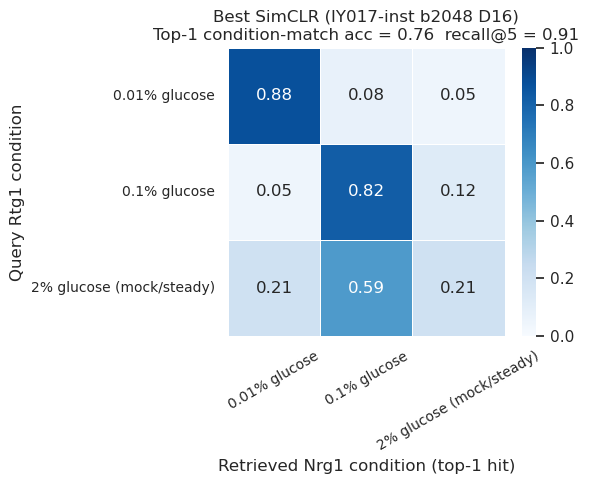

Saved: IY032_open_set_retrieval_bar.png


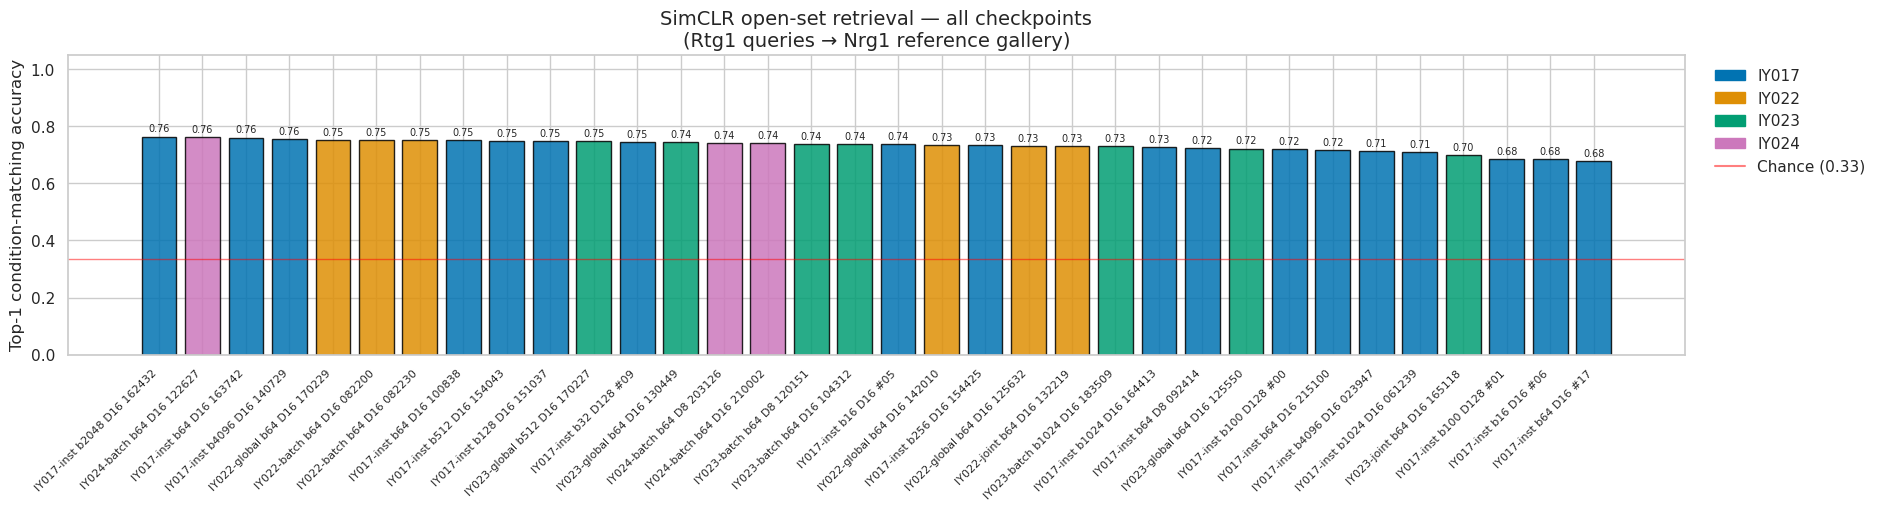

In [10]:
def retrieval_distribution_matrix(top1_pred, y_query, n_ref, n_query):
    """Compute fraction of top-1 hits per (query class, reference class) pair."""
    mat = np.zeros((n_query, n_ref))
    for q_idx in range(n_query):
        mask  = y_query == q_idx
        preds = top1_pred[mask]
        for r_idx in range(n_ref):
            mat[q_idx, r_idx] = (preds == r_idx).sum() / mask.sum()
    return mat


def plot_retrieval_heatmap(mat, ax, ref_labels, query_labels, title, cmap="Blues"):
    """Plot a retrieval distribution matrix as a heatmap."""
    sns.heatmap(
        mat, annot=True, fmt=".2f",
        xticklabels=ref_labels, yticklabels=query_labels,
        cmap=cmap, vmin=0, vmax=1, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_xlabel("Retrieved Nrg1 condition (top-1 hit)", fontsize=12)
    ax.set_ylabel("Query Rtg1 condition", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=10)


# ── Retrieval distribution heatmap for best SimCLR model ────────────────────
best_mat = retrieval_distribution_matrix(
    best_result["top1_pred"], retrieval["y_query"], n_ref, n_query
)

fig, ax = plt.subplots(figsize=(6, 5))
plot_retrieval_heatmap(
    best_mat, ax, ref_short, query_short,
    title=(f"Best SimCLR ({best_row['short_label']})\n"
           f"Top-1 condition-match acc = {best_result['acc_top1']:.2f}  "
           f"recall@{K} = {best_result['recall_at_k']:.2f}"),
)
plt.tight_layout()
fig.savefig(IY032_DIR / "IY032_open_set_retrieval_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_retrieval_heatmap.png")
plt.show()

# ── Per-checkpoint bar chart (top-1 accuracy) ────────────────────────────────
valid_df   = retrieval_df[retrieval_df["status"] == "ok"].copy()
bar_colors = [EXP_COLOR_MAP.get(exp, (0.5,) * 3) for exp in valid_df["experiment"]]

fig, ax = plt.subplots(figsize=(max(14, len(valid_df) * 0.55), 5), constrained_layout=True)
bars = ax.bar(range(len(valid_df)), valid_df["acc_top1"],
              color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="red", linestyle="-", lw=1.0, alpha=0.5,
           label=f"Chance ({chance:.2f})")
ax.set_xticks(range(len(valid_df)))
ax.set_xticklabels(valid_df["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Top-1 condition-matching accuracy")
ax.set_title("SimCLR open-set retrieval — all checkpoints\n(Rtg1 queries → Nrg1 reference gallery)", fontsize=14)
for bar, v in zip(bars, valid_df["acc_top1"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{v:.2f}", ha="center", va="bottom", fontsize=7)

palette = sns.color_palette("colorblind")
legend_handles = [
    Patch(color=EXP_COLOR_MAP.get(_d, palette[7]), label=_d.replace("EXP-26-", ""))
    for _d in CKPT_DIRS
] + [plt.Line2D([0], [0], color="red", ls="-", alpha=0.5, label=f"Chance ({chance:.2f})")]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
fig.savefig(IY032_DIR / "IY032_open_set_retrieval_bar.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_retrieval_bar.png")
plt.show()

## 6. Visualise the embedding space
Plot a UMAP of reference + query embeddings together, colouring by:

TF identity (to see if Rtg1 lands near Nrg1)
Condition (to see if glucose concentration drives clustering across TFs)
This is the most interpretable figure for the zero-shot claim.


SimCLR ref+query PCA explained variance: 0.78
    SGD-MDS may not have converged: stress changed by 2.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Saved: IY032_open_set_umap_by_tf.png


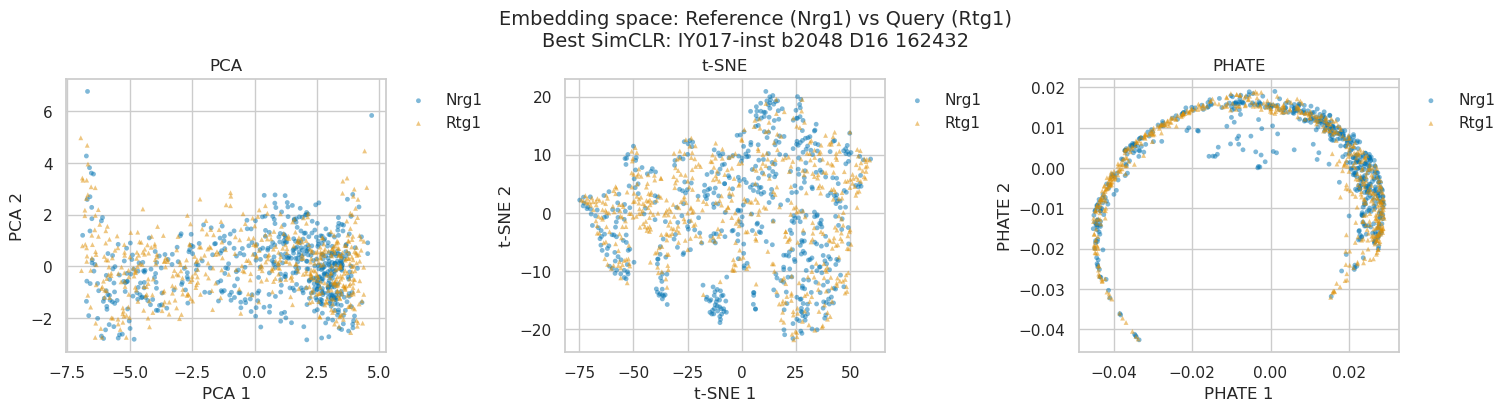

Saved: IY032_open_set_umap_by_condition.png


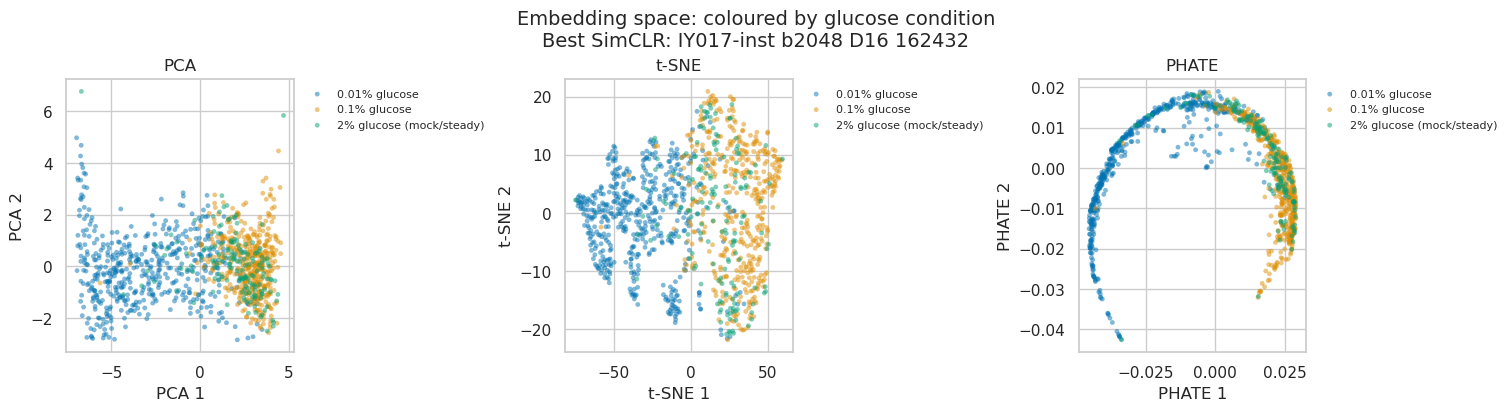

In [11]:
from utils.embeddings import reduce_embeddings

# Pool reference gallery + query probes into one matrix
Z_all       = np.vstack([Z_ref_best_sc, Z_query_best_sc])
n_ref_cells = len(Z_ref_best_sc)
tf_labels   = (["Nrg1"] * n_ref_cells) + (["Rtg1"] * len(Z_query_best_sc))
cond_labels = (
    [retrieval["ref_class_names"][i].split(" @ ")[1]   for i in retrieval["y_ref"]] +
    [retrieval["query_class_names"][i].split(" @ ")[1] for i in retrieval["y_query"]]
)

projs = reduce_embeddings(Z_all, name="SimCLR ref+query", random_state=RANDOM_STATE)

tf_arr       = np.array(tf_labels)
cond_arr     = np.array(cond_labels)
unique_conds = sorted(set(cond_labels))
tf_palette   = dict(zip(["Nrg1", "Rtg1"], sns.color_palette("colorblind", 2)))
cond_palette = dict(zip(unique_conds, sns.color_palette("colorblind", len(unique_conds))))

# ── Plot 1: colour by TF (Nrg1 vs Rtg1) ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, method in zip(axes, ["PCA", "t-SNE", "PHATE"]):
    coords = projs[method]
    for tf, marker in zip(["Nrg1", "Rtg1"], ["o", "^"]):
        mask = tf_arr == tf
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[tf_palette[tf]], marker=marker, alpha=0.5, s=12,
                   edgecolors="none", label=tf)
    ax.set_title(method, fontsize=12)
    ax.set_xlabel(f"{method} 1", fontsize=12)
    ax.set_ylabel(f"{method} 2", fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
fig.suptitle(f"Embedding space: Reference (Nrg1) vs Query (Rtg1)\n"
             f"Best SimCLR: {best_row['label']}", fontsize=14)
fig.savefig(IY032_DIR / "IY032_open_set_umap_by_tf.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_umap_by_tf.png")
plt.show()

# ── Plot 2: colour by glucose condition ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, method in zip(axes, ["PCA", "t-SNE", "PHATE"]):
    coords = projs[method]
    for cond in unique_conds:
        mask = cond_arr == cond
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[cond_palette[cond]], alpha=0.5, s=12,
                   edgecolors="none", label=cond)
    ax.set_title(method, fontsize=12)
    ax.set_xlabel(f"{method} 1", fontsize=12)
    ax.set_ylabel(f"{method} 2", fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=8)
fig.suptitle(f"Embedding space: coloured by glucose condition\n"
             f"Best SimCLR: {best_row['label']}", fontsize=14)
fig.savefig(IY032_DIR / "IY032_open_set_umap_by_condition.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_umap_by_condition.png")
plt.show()

## 7. Compare to baselines
Run the same retrieval procedure using raw time-series KNN and Catch22+KNN features (both already available from IY032), using cosine or Euclidean distance directly. This gives a like-for-like comparison against SimCLR.


## 7a. Diagnostic: mean traces and raw-space geometry

The raw time-series baseline achieves **top-1 acc = 0.11**, well below chance (0.33). The heatmap shows a clear anti-diagonal pattern (Rtg1@0.01% → Nrg1@2% 99%; Rtg1@0.1% → Nrg1@0.01% 57%). 

**Hypothesis:** Rtg1 and Nrg1 have *inverted* steady-state nuclear localizations at the same glucose condition:

| Condition | Rtg1 | Nrg1 |
|---|---|---|
| 0.01% glucose (low) | nuclear (active) | cytoplasmic (inactive) |
| 2% glucose (mock/steady) | cytoplasmic (inactive) | nuclear (active) |

If correct, raw euclidean retrieval will match Rtg1@low-glucose to Nrg1@high-glucose (both nuclear), giving the anti-diagonal pattern and below-chance accuracy. The cells below verify this.

Saved: IY032_open_set_diagnostic_mean_traces.png


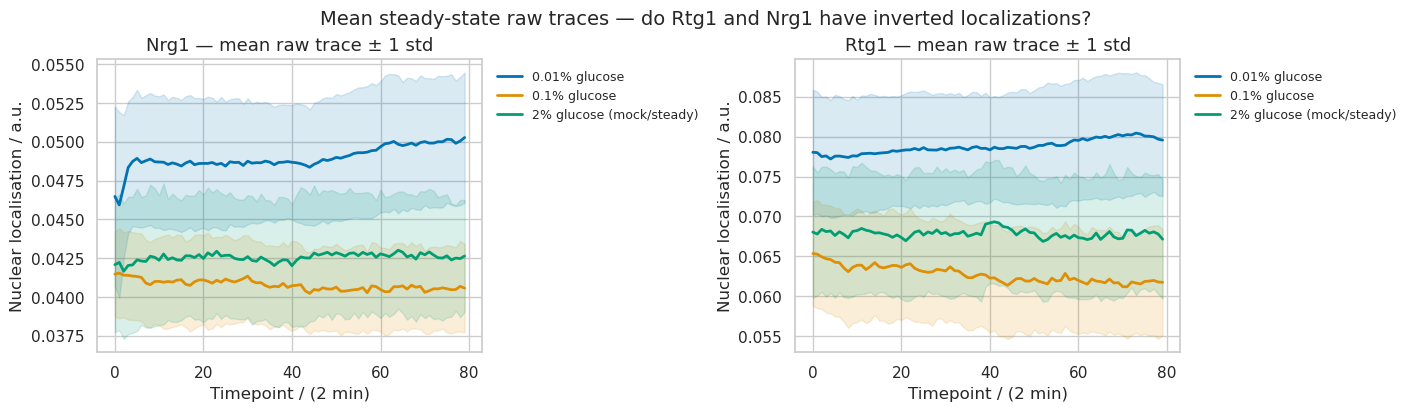

Saved: IY032_open_set_diagnostic_centroid_dist.png


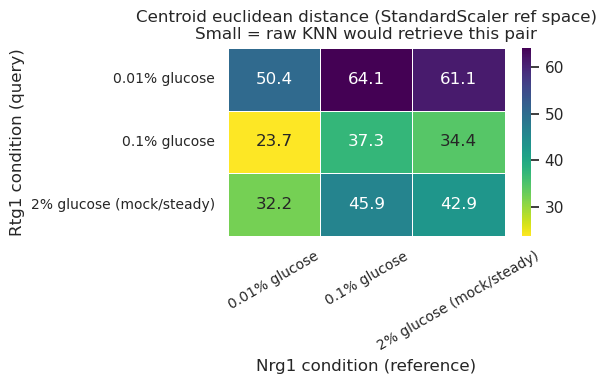


Cross-TF centroid distances (Rtg1 query → Nrg1 ref):
                                                0.01% glucose         0.1% glucose 2% glucose (mock/steady)
  Rtg1 @ 0.01% glucose                                    50.38                64.11                61.15   → nearest: 0.01% glucose
  Rtg1 @ 0.1% glucose                                     23.73                37.30                34.38   → nearest: 0.01% glucose
  Rtg1 @ 2% glucose (mock/steady)                         32.18                45.85                42.91   → nearest: 0.01% glucose


In [15]:
pal = sns.color_palette("colorblind")

# ── Plot 1: mean raw trace per class ─────────────────────────────────────────
all_classes_raw = {
    **{retrieval["ref_class_names"][i]:   retrieval["X_ref_raw"][retrieval["y_ref"] == i]
       for i in range(n_ref)},
    **{retrieval["query_class_names"][i]: retrieval["X_query_raw"][retrieval["y_query"] == i]
       for i in range(n_query)},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True, sharey=False)
cond_colors = {
    "0.01% glucose":            pal[0],
    "0.1% glucose":             pal[1],
    "2% glucose (mock/steady)": pal[2],
}
for ax, tf in zip(axes, ["Nrg1", "Rtg1"]):
    for cls_name, X in all_classes_raw.items():
        if not cls_name.startswith(tf):
            continue
        cond = cls_name.split(" @ ")[1]
        mean_trace = X.mean(axis=0)
        ax.plot(mean_trace, label=cond, color=cond_colors[cond], lw=2)
        ax.fill_between(range(len(mean_trace)),
                        mean_trace - X.std(axis=0),
                        mean_trace + X.std(axis=0),
                        color=cond_colors[cond], alpha=0.15)
    ax.set_title(f"{tf} — mean raw trace ± 1 std", fontsize=13)
    ax.set_xlabel("Timepoint / (2 min)", fontsize=12)
    ax.set_ylabel("Nuclear localisation / a.u.", fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)
fig.suptitle("Mean steady-state raw traces — do Rtg1 and Nrg1 have inverted localizations?",
             fontsize=14)
fig.savefig(IY032_DIR / "IY032_open_set_diagnostic_mean_traces.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_diagnostic_mean_traces.png")
plt.show()

# ── Plot 2: cross-TF centroid distances (Rtg1 rows × Nrg1 cols) ──────────────
# 3×3 matrix only — same layout as the retrieval heatmaps.
# Nrg1 (reference) on x-axis, Rtg1 (query) on y-axis.
scaler_diag  = StandardScaler()
X_ref_diag   = scaler_diag.fit_transform(retrieval["X_ref_raw"])
X_query_diag = scaler_diag.transform(retrieval["X_query_raw"])

ref_centroids   = {retrieval["ref_class_names"][i]:   X_ref_diag[retrieval["y_ref"] == i].mean(axis=0)
                   for i in range(n_ref)}
query_centroids = {retrieval["query_class_names"][i]: X_query_diag[retrieval["y_query"] == i].mean(axis=0)
                   for i in range(n_query)}

# Build 3×3 distance matrix: rows = Rtg1 queries, cols = Nrg1 reference
cross_dist = np.array([
    [np.linalg.norm(q_vec - r_vec) for r_vec in ref_centroids.values()]
    for q_vec in query_centroids.values()
])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cross_dist, annot=True, fmt=".1f",
            xticklabels=ref_short, yticklabels=query_short,
            cmap="viridis_r", ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Nrg1 condition (reference)", fontsize=12)
ax.set_ylabel("Rtg1 condition (query)", fontsize=12)
ax.set_title("Centroid euclidean distance (StandardScaler ref space)\n"
             "Small = raw KNN would retrieve this pair", fontsize=12)
ax.tick_params(axis="x", rotation=30, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
fig.savefig(IY032_DIR / "IY032_open_set_diagnostic_centroid_dist.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_diagnostic_centroid_dist.png")
plt.show()

# ── Numeric summary ───────────────────────────────────────────────────────────
print("\nCross-TF centroid distances (Rtg1 query → Nrg1 ref):")
print(f"{'':40s}", " ".join(f"{n.replace('Nrg1 @ ',''):>20s}" for n in ref_centroids))
for q_name, dists in zip(query_centroids, cross_dist):
    nearest = list(ref_centroids)[np.argmin(dists)]
    print(f"  {q_name:40s}", " ".join(f"{d:20.2f}" for d in dists),
          f"  → nearest: {nearest.replace('Nrg1 @ ', '')}")

=== Baseline 1: Raw time-series (euclidean) ===
  top-1 condition-matching acc : 0.1085  (+-0.2248 vs chance)
  recall@5                   : 0.6130

=== Baseline 2: Catch22 features (euclidean) ===


  top-1 condition-matching acc : 0.4051  (+0.0717 vs chance)
  recall@5                   : 0.8246

Saved: IY032_open_set_baseline_heatmaps.png


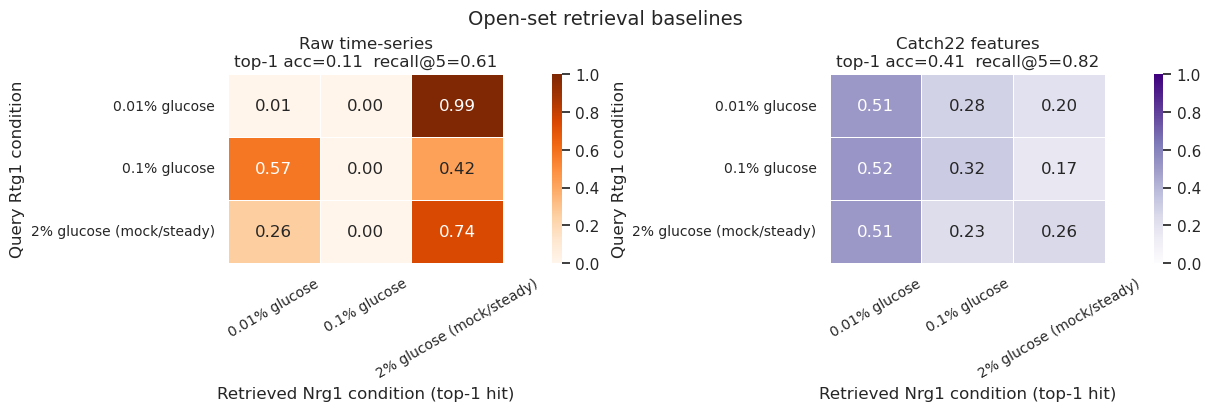

In [13]:
from features.catch22 import extract_catch22, fill_feature_frame

# ── Baseline 1: Raw time-series (euclidean) ───────────────────────────────────
print("=== Baseline 1: Raw time-series (euclidean) ===")
scaler_raw   = StandardScaler()
X_ref_raw_sc = scaler_raw.fit_transform(retrieval["X_ref_raw"])
X_q_raw_sc   = scaler_raw.transform(retrieval["X_query_raw"])
raw_result   = open_set_retrieve(X_ref_raw_sc, retrieval["y_ref"],
                                  X_q_raw_sc,   retrieval["y_query"],
                                  k=K)
print(f"  top-1 condition-matching acc : {raw_result['acc_top1']:.4f}  "
      f"(+{raw_result['acc_top1'] - chance:.4f} vs chance)")
print(f"  recall@{K}                   : {raw_result['recall_at_k']:.4f}")

# ── Baseline 2: Catch22 features (euclidean) ─────────────────────────────────
print("\n=== Baseline 2: Catch22 features (euclidean) ===")
X_ref_c22_df   = extract_catch22(list(retrieval["X_ref_raw"]),   desc="Reference (Catch22)")
X_query_c22_df = extract_catch22(list(retrieval["X_query_raw"]), desc="Query (Catch22)")
# fill_feature_frame treats reference as "train" (provides median fills) and query as "test"
X_ref_c22_df, X_query_c22_df = fill_feature_frame(X_ref_c22_df, X_query_c22_df)
scaler_c22   = StandardScaler()
X_ref_c22_sc = scaler_c22.fit_transform(X_ref_c22_df.values)
X_q_c22_sc   = scaler_c22.transform(X_query_c22_df.values)
c22_result   = open_set_retrieve(X_ref_c22_sc, retrieval["y_ref"],
                                  X_q_c22_sc,   retrieval["y_query"],
                                  k=K)
print(f"  top-1 condition-matching acc : {c22_result['acc_top1']:.4f}  "
      f"(+{c22_result['acc_top1'] - chance:.4f} vs chance)")
print(f"  recall@{K}                   : {c22_result['recall_at_k']:.4f}")

# ── Baseline heatmaps side-by-side ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, result, title, cmap in zip(
    axes,
    [raw_result,   c22_result],
    ["Raw time-series", "Catch22 features"],
    ["Oranges",    "Purples"],
):
    mat = retrieval_distribution_matrix(result["top1_pred"], retrieval["y_query"], n_ref, n_query)
    plot_retrieval_heatmap(mat, ax, ref_short, query_short,
                           title=f"{title}\ntop-1 acc={result['acc_top1']:.2f}  recall@{K}={result['recall_at_k']:.2f}",
                           cmap=cmap)
fig.suptitle("Open-set retrieval baselines", fontsize=14)
fig.savefig(IY032_DIR / "IY032_open_set_baseline_heatmaps.png", dpi=150, bbox_inches="tight")
print("\nSaved: IY032_open_set_baseline_heatmaps.png")
plt.show()

## 8. Interpret
The key question: does SimCLR route Rtg1 queries to the biologically plausible Nrg1@matching-condition class significantly more than chance (1/3 if 3 reference classes), and significantly more than the baselines?

Saved: IY032_open_set_summary.png


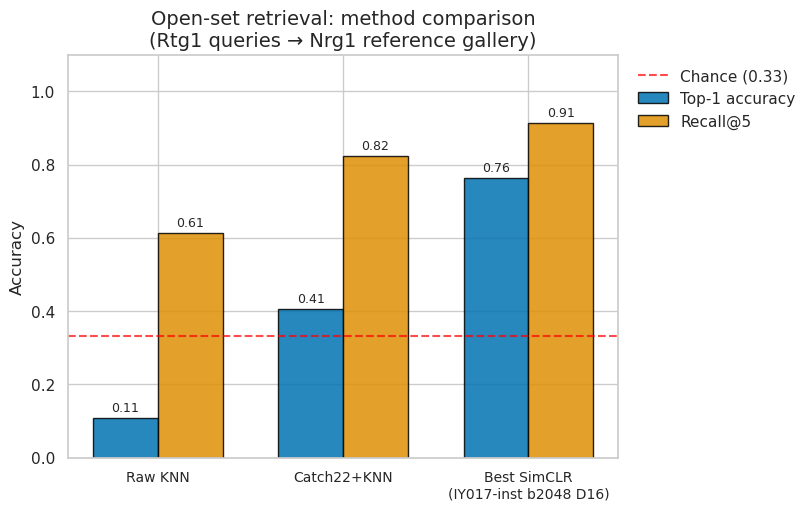


OPEN-SET RETRIEVAL SUMMARY  (Rtg1 queries → Nrg1 reference library)
Shared T = 80 tp  |  Gallery: 546 cells  |  Queries: 553 cells
Chance (condition-matching): 1/3 = 0.3333

Method                               Top-1   Recall@5
-------------------------------------------------------
Raw KNN                             0.1085     0.6130
Catch22+KNN                         0.4051     0.8246
Best SimCLR (IY017-inst b2048 D16)  0.7631     0.9132


In [14]:
method_labels = ["Raw KNN", "Catch22+KNN", f"Best SimCLR\n({best_row['short_label']})"]
top1_accs     = [raw_result["acc_top1"],   c22_result["acc_top1"],   best_result["acc_top1"]]
recall_accs   = [raw_result["recall_at_k"], c22_result["recall_at_k"], best_result["recall_at_k"]]

x     = np.arange(len(method_labels))
width = 0.35
pal   = sns.color_palette("colorblind")

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bars1 = ax.bar(x - width / 2, top1_accs,   width, label="Top-1 accuracy",
               color=pal[0], alpha=0.85, edgecolor="black")
bars2 = ax.bar(x + width / 2, recall_accs, width, label=f"Recall@{K}",
               color=pal[1], alpha=0.85, edgecolor="black")
ax.axhline(chance, color="red", linestyle="--", lw=1.5, alpha=0.7,
           label=f"Chance ({chance:.2f})")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(method_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Open-set retrieval: method comparison\n(Rtg1 queries → Nrg1 reference gallery)", fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
fig.savefig(IY032_DIR / "IY032_open_set_summary.png", dpi=150, bbox_inches="tight")
print("Saved: IY032_open_set_summary.png")
plt.show()

# ── Numeric summary ───────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("OPEN-SET RETRIEVAL SUMMARY  (Rtg1 queries → Nrg1 reference library)")
print(f"{'='*65}")
print(f"Shared T = {retrieval['shared_min_T']} tp  |  "
      f"Gallery: {len(retrieval['y_ref'])} cells  |  "
      f"Queries: {len(retrieval['y_query'])} cells")
print(f"Chance (condition-matching): 1/{n_ref} = {chance:.4f}")
print(f"\n{'Method':<34s}  {'Top-1':>6s}  {'Recall@'+str(K):>9s}")
print("-" * 55)
for m, t1, rk in zip(method_labels, top1_accs, recall_accs):
    print(f"{m.replace(chr(10), ' '):<34s}  {t1:>6.4f}  {rk:>9.4f}")